In [1]:
!pip install pandas numpy pyarrow seaborn

In [2]:
import pandas as pd

#### Una vez ya instalado e importado pandas leemos el dataset que viene en un archivo .csv

In [3]:
df = pd.read_csv("sales_train_evaluation.csv")
print(df)

                                  id        item_id    dept_id   cat_id  \
0      HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES   
1      HOBBIES_1_002_CA_1_evaluation  HOBBIES_1_002  HOBBIES_1  HOBBIES   
2      HOBBIES_1_003_CA_1_evaluation  HOBBIES_1_003  HOBBIES_1  HOBBIES   
3      HOBBIES_1_004_CA_1_evaluation  HOBBIES_1_004  HOBBIES_1  HOBBIES   
4      HOBBIES_1_005_CA_1_evaluation  HOBBIES_1_005  HOBBIES_1  HOBBIES   
...                              ...            ...        ...      ...   
30485    FOODS_3_823_WI_3_evaluation    FOODS_3_823    FOODS_3    FOODS   
30486    FOODS_3_824_WI_3_evaluation    FOODS_3_824    FOODS_3    FOODS   
30487    FOODS_3_825_WI_3_evaluation    FOODS_3_825    FOODS_3    FOODS   
30488    FOODS_3_826_WI_3_evaluation    FOODS_3_826    FOODS_3    FOODS   
30489    FOODS_3_827_WI_3_evaluation    FOODS_3_827    FOODS_3    FOODS   

      store_id state_id  d_1  d_2  d_3  d_4  ...  d_1932  d_1933  d_1934  \
0         CA_1       CA

In [4]:
from numpy import int16

#Filtrando por columnas que empiecen con d_ y guardandolas en una variable
cols_d = df.filter(like='d_').columns

# Llenar NaN values en la columna 'days' DataFrame y luego convertir a int16

df[cols_d].fillna(0).astype(int16)

# Convirtiendo la columna d_nday a una fila dentro de days
df_long = pd.melt(df, id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],var_name="days",value_name="sales")




# Convirtiendo sales de float 64 a int16 con el objetivo de optimizar RAM
df_long['sales'] = df_long['sales'].fillna(0).astype(int16)



print(df_long.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59181090 entries, 0 to 59181089
Data columns (total 8 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   id        object
 1   item_id   object
 2   dept_id   object
 3   cat_id    object
 4   store_id  object
 5   state_id  object
 6   days      object
 7   sales     int16 
dtypes: int16(1), object(7)
memory usage: 3.2+ GB
None


In [5]:
# Borrando Dataframe para consumir menos RAM
import gc

del df

gc.collect()


0

In [6]:
# Convirtiendo columnas de texto a categorias

df_long['id'] = df_long['id'].astype('category')
df_long['item_id'] = df_long['item_id'].astype('category')
df_long['dept_id'] = df_long['dept_id'].astype('category')
df_long['cat_id'] = df_long['cat_id'].astype('category')
df_long['store_id'] = df_long['store_id'].astype('category')
df_long['state_id'] = df_long['state_id'].astype('category')
df_long['days'] = df_long['days'].astype('category')

print(df_long.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59181090 entries, 0 to 59181089
Data columns (total 8 columns):
 #   Column    Dtype   
---  ------    -----   
 0   id        category
 1   item_id   category
 2   dept_id   category
 3   cat_id    category
 4   store_id  category
 5   state_id  category
 6   days      category
 7   sales     int16   
dtypes: category(7), int16(1)
memory usage: 678.7 MB
None


#### Optimizar a calendar.csv


In [7]:
df2 = pd.read_csv("calendar.csv")

cols_d2 = df2.filter(like='snap').columns

# Conviertiendo Snap a bool, ya que siempre va a tener dos valores, Snap es la ayuda que da el gobierno de los Estados Unidos a sus ciudadanos
df2[cols_d2] = df2[cols_d2].astype(bool)

# Convirtiendo columnas a categorías
df2['event_name_1'] = df2['event_name_1'].fillna("None").astype('category')
df2['event_name_2'] = df2['event_name_2'].fillna("None").astype('category')
df2['event_type_1'] = df2['event_type_1'].fillna("None").astype('category')
df2['event_type_2'] = df2['event_type_2'].fillna("None").astype('category')

#Convirtiendo d en categoria para el merge

df2['d'] = df2['d'].astype('category')

#Convirtiendo date em un datetime

df2['date'] = pd.to_datetime(df2['date'])



print(df2.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1969 non-null   datetime64[ns]
 1   wm_yr_wk      1969 non-null   int64         
 2   weekday       1969 non-null   object        
 3   wday          1969 non-null   int64         
 4   month         1969 non-null   int64         
 5   year          1969 non-null   int64         
 6   d             1969 non-null   category      
 7   event_name_1  1969 non-null   category      
 8   event_type_1  1969 non-null   category      
 9   event_name_2  1969 non-null   category      
 10  event_type_2  1969 non-null   category      
 11  snap_CA       1969 non-null   bool          
 12  snap_TX       1969 non-null   bool          
 13  snap_WI       1969 non-null   bool          
dtypes: bool(3), category(5), datetime64[ns](1), int64(4), object(1)
memory usage: 191.5+ KB


#### Merge entre sales sales_train_evaluation.csv y calendar.csv





In [8]:

df1 = df_long

df_final = df1.merge(df2, left_on="days", right_on="d")

print(df_final.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59181090 entries, 0 to 59181089
Data columns (total 22 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            category      
 1   item_id       category      
 2   dept_id       category      
 3   cat_id        category      
 4   store_id      category      
 5   state_id      category      
 6   days          object        
 7   sales         int16         
 8   date          datetime64[ns]
 9   wm_yr_wk      int64         
 10  weekday       object        
 11  wday          int64         
 12  month         int64         
 13  year          int64         
 14  d             category      
 15  event_name_1  category      
 16  event_type_1  category      
 17  event_name_2  category      
 18  event_type_2  category      
 19  snap_CA       bool          
 20  snap_TX       bool          
 21  snap_WI       bool          
dtypes: bool(3), category(11), datetime64[ns](1), int16(1), int64(4),

In [9]:
# Borrando Dataframe para consumir menos RAM
import gc

del df1
del df2
del df_long

gc.collect()

0

In [10]:
# Busca filas donde 'sales' tenga un valor de 0
percentage = df_final['sales'] == 0

# Cuenta y suma las filas con valor 0 en 'sales'
counting_zero = percentage.sum()
len(df_final)

result = counting_zero / len(df_final) * 100


print(result)

67.99776584040612


#### Casi 7 de cada 10 registros son ceros



In [11]:
average_sales = df_final.groupby('event_name_1')['sales'].mean()

print(average_sales)



/tmp/ipykernel_12976/767604793.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_sales = df_final.groupby('event_name_1')['sales'].mean()


event_name_1
Chanukah End           1.096320
Christmas              0.000512
Cinco De Mayo          1.128613
ColumbusDay            1.153322
Easter                 1.296084
Eid al-Fitr            1.156694
EidAlAdha              1.131650
Father's day           1.199147
Halloween              0.985877
IndependenceDay        1.105635
LaborDay               1.382571
LentStart              1.007773
LentWeek2              0.975631
MartinLutherKingDay    1.094739
MemorialDay            1.072470
Mother's day           1.184356
NBAFinalsEnd           1.100827
NBAFinalsStart         1.045405
NewYear                0.845143
None                   1.135105
OrthodoxChristmas      1.093611
OrthodoxEaster         1.352181
Pesach End             1.189898
PresidentsDay          1.129758
Purim End              1.179305
Ramadan starts         1.140689
StPatricksDay          1.097398
SuperBowl              1.342211
Thanksgiving           0.693014
ValentinesDay          1.098579
VeteransDay            1.15

#### Los dias en los que hay mayor venta son LaborDay, Easter, Father's day,

In [12]:
#Calcula el promedio de ventas en un dia de semana
week_day_sales = df_final.groupby('weekday')['sales'].mean()

print(week_day_sales)


weekday
Friday       1.126844
Monday       1.082156
Saturday     1.367867
Sunday       1.354675
Thursday     0.994459
Tuesday      1.000344
Wednesday    0.988207
Name: sales, dtype: float64


#### Los dias en los que hay mayor venta son los Saturday (Sabado) & Sunday (Domingo)

In [13]:
df = pd.read_csv('sell_prices.csv')
print(df)

        store_id        item_id  wm_yr_wk  sell_price
0           CA_1  HOBBIES_1_001     11325        9.58
1           CA_1  HOBBIES_1_001     11326        9.58
2           CA_1  HOBBIES_1_001     11327        8.26
3           CA_1  HOBBIES_1_001     11328        8.26
4           CA_1  HOBBIES_1_001     11329        8.26
...          ...            ...       ...         ...
6841116     WI_3    FOODS_3_827     11617        1.00
6841117     WI_3    FOODS_3_827     11618        1.00
6841118     WI_3    FOODS_3_827     11619        1.00
6841119     WI_3    FOODS_3_827     11620        1.00
6841120     WI_3    FOODS_3_827     11621        1.00

[6841121 rows x 4 columns]


In [14]:
from numpy import int16, float32

# Convirtiendo columnas a categorías
df['store_id'] = df['store_id'].astype('category')
df['item_id'] = df['item_id'].astype('category')
df['wm_yr_wk'] = df['wm_yr_wk'].astype(int16)
df['sell_price'] = df['sell_price'].astype(float32)


print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype   
---  ------      -----   
 0   store_id    category
 1   item_id     category
 2   wm_yr_wk    int16   
 3   sell_price  float32 
dtypes: category(2), float32(1), int16(1)
memory usage: 58.8 MB
None


#### Merge entre sales df_final y sell_prices.csv


In [15]:
df_final = df_final.merge(df, on = ['store_id', 'item_id','wm_yr_wk'], how='left')

sales = df_final.groupby('cat_id')['sales'].sum()

print(sales)



/tmp/ipykernel_12976/1742765843.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales = df_final.groupby('cat_id')['sales'].sum()


cat_id
FOODS        45922427
HOBBIES       6240656
HOUSEHOLD    14764090
Name: sales, dtype: int64


#### La categoria que tiene mayor ventas es "FOODS"

In [16]:
# Elimnando columnas duplicadas

df_final = df_final.drop(columns=['sell_price_x', 'sell_price_y'], errors='ignore')

df_final = df_final.dropna(subset=['sell_price'])

# Verificar Datos nulos para la integridad de datos

print("Estado de nulos en el dataset:")
print(df_final.isnull().sum())

# 4. Verificamos el tamaño final (debería haber bajado de 59M a unos 47M aprox)
print(f"\nTotal de filas después de la limpieza: {len(df_final)}")


Estado de nulos en el dataset:
id              0
item_id         0
dept_id         0
cat_id          0
store_id        0
state_id        0
days            0
sales           0
date            0
wm_yr_wk        0
weekday         0
wday            0
month           0
year            0
d               0
event_name_1    0
event_type_1    0
event_name_2    0
event_type_2    0
snap_CA         0
snap_TX         0
snap_WI         0
sell_price      0
dtype: int64

Total de filas después de la limpieza: 46881677


#### Verificamos la variación del precio

In [19]:
# Contamos cuántos precios distintos ha tenido cada producto en cada tienda
# Esto valida si el precio es una variable dinámica (útil) o estática (ruido)
variabilidad = df_final.groupby(['store_id', 'item_id'])['sell_price'].nunique()

print("Resumen de variabilidad de precios (nunique):")
print(variabilidad.describe())

/tmp/ipykernel_12976/3771162589.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  variabilidad = df_final.groupby(['store_id', 'item_id'])['sell_price'].nunique()


Resumen de variabilidad de precios (nunique):
count    30490.000000
mean         2.753427
std          1.849128
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         21.000000
Name: sell_price, dtype: float64


In [20]:
# 1. Encontrar el item_id que más vende en una tienda específica (ej: CA_1)
top_item = df_final[df_final['store_id'] == 'CA_1'].groupby('item_id')['sales'].sum().idxmax()
print(f"Graficando el producto estrella: {top_item}")

# 2. Filtrar los datos solo para ese producto en esa tienda
df_plot = df_final[(df_final['item_id'] == top_item) & (df_final['store_id'] == 'CA_1')].copy()
df_plot = df_plot.sort_values('date')

Graficando el producto estrella: FOODS_3_090


/tmp/ipykernel_12976/2949055775.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_item = df_final[df_final['store_id'] == 'CA_1'].groupby('item_id')['sales'].sum().idxmax()


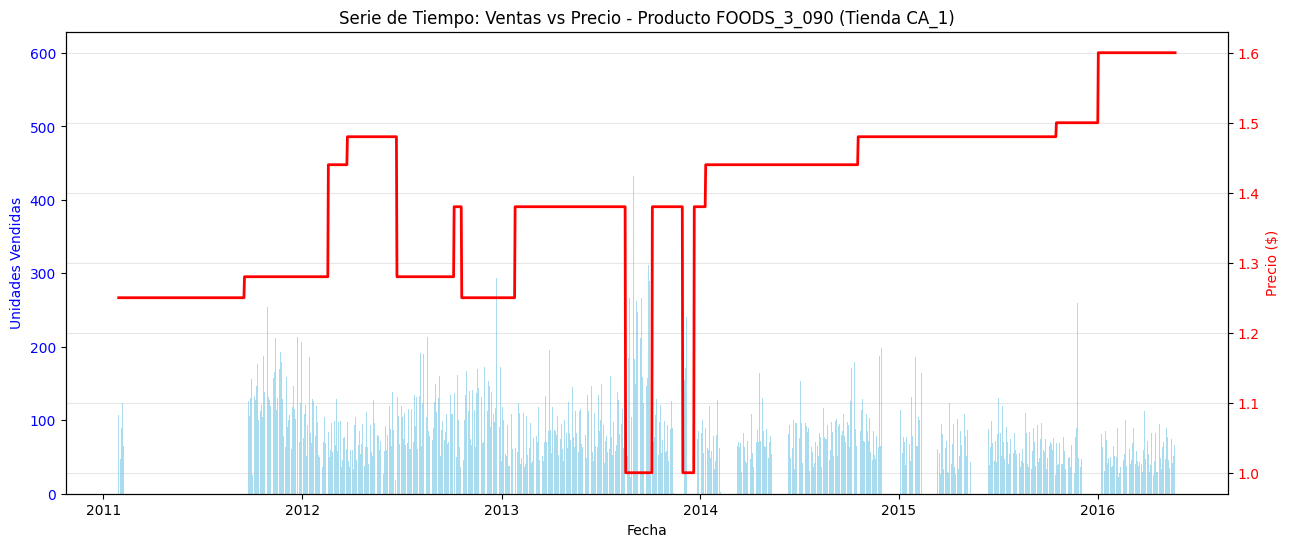

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(15, 6))

# Eje 1: Ventas (Barras para ver la intermitencia/ceros)
ax1.bar(df_plot['date'], df_plot['sales'], color='skyblue', alpha=0.7, label='Ventas Diarias')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Unidades Vendidas', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Eje 2: Precio (Línea para ver cambios/promociones)
ax2 = ax1.twinx()
ax2.plot(df_plot['date'], df_plot['sell_price'], color='red', lw=2, label='Precio de Venta')
ax2.set_ylabel('Precio ($)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title(f'Serie de Tiempo: Ventas vs Precio - Producto {top_item} (Tienda CA_1)')
plt.grid(True, alpha=0.3)
plt.show()

#### Grafico de dispersión Precio Vs Ventas

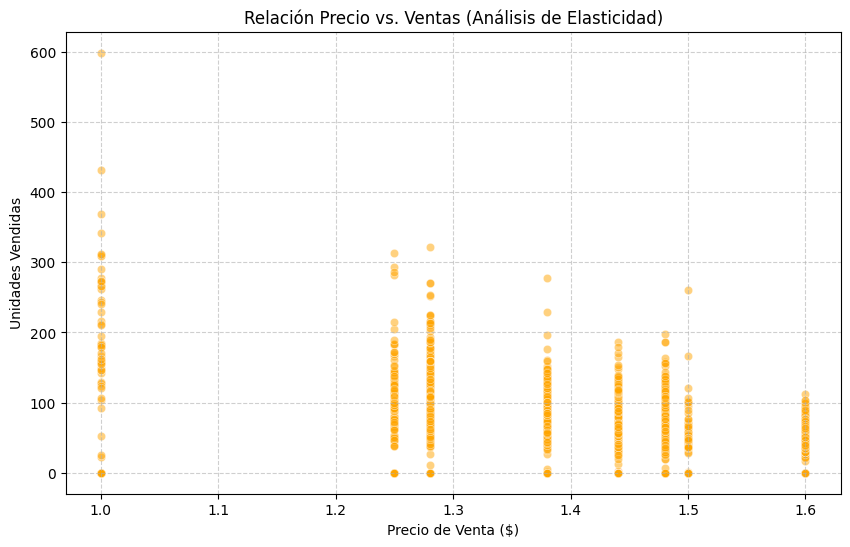

Correlación de Pearson: -0.2238


In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='sell_price', y='sales', alpha=0.5, color='orange')
plt.title('Relación Precio vs. Ventas (Análisis de Elasticidad)')
plt.xlabel('Precio de Venta ($)')
plt.ylabel('Unidades Vendidas')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Opcional: Calcular la correlación numérica
print(f"Correlación de Pearson: {df_plot['sell_price'].corr(df_plot['sales']):.4f}")

#### Impacto SNAP (Ayuda del gobierno)

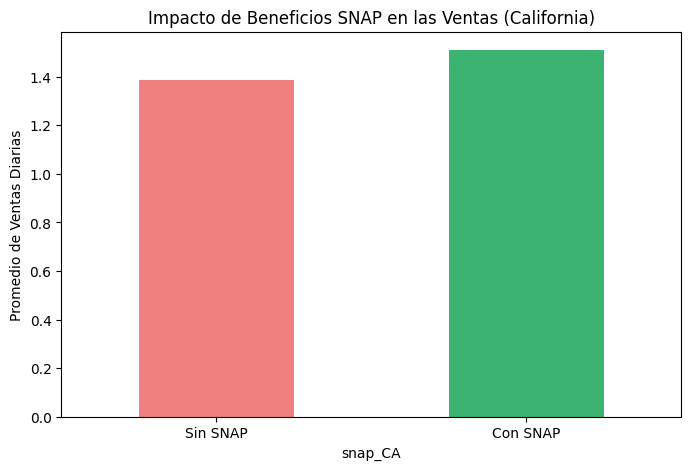

In [23]:
snap_analysis = df_final.groupby('snap_CA')['sales'].mean()

plt.figure(figsize=(8, 5))
snap_analysis.plot(kind='bar', color=['lightcoral', 'mediumseagreen'])
plt.xticks([0, 1], ['Sin SNAP', 'Con SNAP'], rotation=0)
plt.title('Impacto de Beneficios SNAP en las Ventas (California)')
plt.ylabel('Promedio de Ventas Diarias')
plt.show()

In [24]:
print("Resumen de Cardinalidad:")
for col in ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']:
    print(f"- {col}: {df_final[col].nunique()} valores únicos")


Resumen de Cardinalidad:
- item_id: 3049 valores únicos
- dept_id: 7 valores únicos
- cat_id: 3 valores únicos
- store_id: 10 valores únicos
- state_id: 3 valores únicos


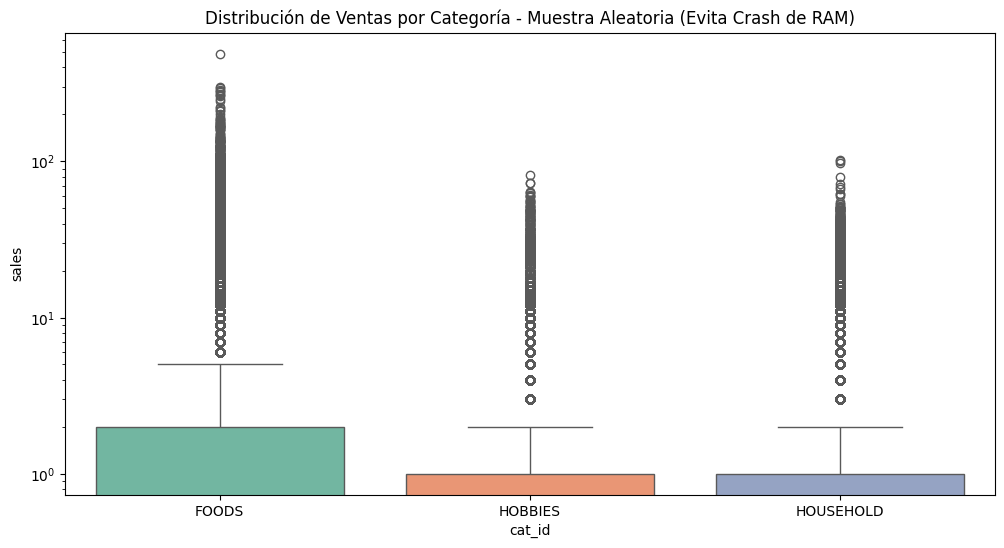

Interpretación: Los outliers en FOODS representan picos de demanda reales. Su presencia justifica el uso de la métrica RMSSE exigida en el informe.


In [25]:
df_sample = df_final.sample(n=1000000, random_state=42)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_sample, x='cat_id', y='sales', hue='cat_id', palette="Set2", legend=False)
plt.yscale('log') # Escala logarítmica para manejar la alta dispersión
plt.title('Distribución de Ventas por Categoría - Muestra Aleatoria')
plt.show()

print("Interpretación: Los outliers en FOODS representan picos de demanda reales. "
      "Su presencia justifica el uso de la métrica RMSSE exigida en el informe.")

In [26]:
dqr_data = {
    "Dimensión": ["Completitud", "Consistencia", "Volumen", "Distribución", "Integridad"],
    "Métrica": ["% de Nulos", "Ventas Negativas", "Total Registros", "% de Ceros", "Variabilidad Precio"],
    "Resultado": ["0.0%", "No detectadas", "46,881,677", "67.99%", "2.75 precios/SKU"],
    "Estado": ["Excelente", "Excelente", "Optimizado", "Riesgo de Sesgo", "Informativo"]
}

dqr_df = pd.DataFrame(dqr_data)
display(dqr_df)

,Dimensión,Métrica,Resultado,Estado
0,Completitud,% de Nulos,0.0%,Excelente
1,Consistencia,Ventas Negativas,No detectadas,Excelente
2,Volumen,Total Registros,"46,881,677",Optimizado
3,Distribución,% de Ceros,67.99%,Riesgo de Sesgo
4,Integridad,Variabilidad Precio,2.75 precios/SKU,Informativo


### Guardamos la data preprocesada

In [ ]:
import os
output_path = "df_preprocessed.parquet"
df_final.to_parquet(output_path, index=False)

print(f"Pipeline Checkpoint: Datos guardados en {output_path}")

### Ejemplo para subir a GitHub

In [ ]:
 df_final.head(100000).to_parquet('sample_processed.parquet')